# VLAB_03 — Generate Long Discharge Time Series

Demonstrates the `generate_network` / `simulate_from_network` split:

1. Generate network.
2. Run **50 MODFLOW realizations** varying only aquifer properties (hk, ss, sy) while holding epikarst (recharge) and network structure fixed.
3. Show results.

In [1]:
import vlab
import numpy as np
import matplotlib.pyplot as plt

## Configuration

In [2]:
N_INLET      = 3                    # number of inlets
INLET_SEED  = 42                    # inlet generation seed
SKS_SEED    = 123                   # network realization seed
N_REAL      = 2                    # LHS realisations of parameters
N_SP        = 50                    # transient stress periods
NROW        = 20                    # number of rows in the model domain
NCOL        = 40                    # number of columns in the model domain

## Helper

In the helper, the stochasticity of different parameter groups is pre-defined.

In [3]:
def make_system(inlet_seed, sks_seed):
    """Build a System with a fixed network topology and stochastic aquifer params."""
    return vlab.System(
        n_rows=NROW,
        n_cols=NCOL,
        n_stress_periods=N_SP,
        groundwater=vlab.Groundwater(nstp=5),
        network_structure=vlab.NetworkStructure(
            stochastic=False,
            n_inlets=N_INLET,
            values={"sks_seed": sks_seed},
            inlets_seed=inlet_seed,
        ),
        recharge_params=vlab.RechargeParams(stochastic=False),
        network_properties=vlab.NetworkProperties(stochastic=True,
                                                  values={
                                                    'k_exchange': 0.001,
                                                    'diameter': 0.5,
                                                    'rheight': 0.02,
                                                    'cad': 0.05}),
        aquifer_params=vlab.AquiferParams(stochastic=False),
    )

## Step 1 — Generate networks

Each of the 9 networks is generated once and stored.  
The MODFLOW loop (Step 2) reuses them without re-running pyKasso.

In [4]:
s = make_system(INLET_SEED, SKS_SEED)
network = s.generate_network(random_state=None, cleanup=True)


Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.


### Recharge

Recharge is fixed and generated at default parameters.

Text(0, 0.5, 'Reacharge flux [mm/d]')

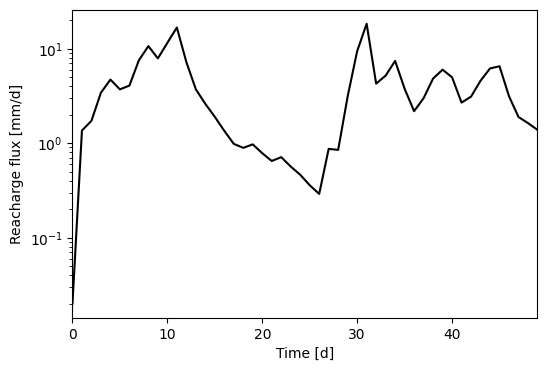

In [5]:
rch = s.simulate_recharge()[:N_SP]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rch, c="k")
ax.set_yscale("log")
ax.set_xlim(0, N_SP - 1)
ax.set_xlabel("Time [d]")
ax.set_ylabel("Reacharge flux [mm/d]")

### Stochastic Network

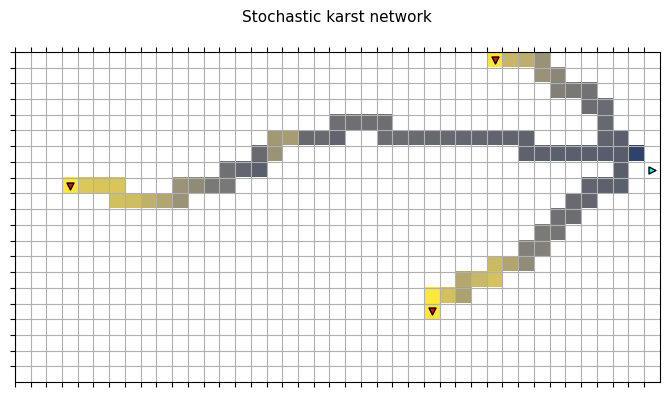

In [6]:
fig, ax = plt.subplots(figsize=(NCOL / 5, NROW / 5))

nplot = network.validator.network.copy().astype(float)
nplot[nplot == 0] = np.nan
ax.matshow(nplot, cmap="cividis", vmin=2, vmax=11)

inlets = np.array(network.idxs_inlet)
ax.scatter(
    inlets[:, 0] - 1, inlets[:, 1] - 1,
    c="r", marker="v", edgecolors="k", s=25, zorder=5,
)
ax.scatter(
    [network.idxs_spring[0]], [network.idxs_spring[1]],
    c="cyan", marker=">", edgecolors="k", s=25, zorder=5,
)

ax.set_xticks([i - .5 for i in range(NCOL+1)])
ax.set_xticklabels([])
ax.set_yticks([i - .5 for i in range(NROW+1)])
ax.set_yticklabels([])

ax.set_xlim(-0.5, NCOL + 0.5)
ax.set_ylim(NROW + 0.5, -0.5)

ax.grid(True)

plt.suptitle("Stochastic karst network", fontsize=11)
plt.tight_layout()
plt.show()

## Step 2 — MODFLOW ensemble

In [7]:
heads_list = []
discharge_list = []
for rs in range(N_REAL):
    success, discharge, heads = s.simulate_from_network(
        network=network, random_state=rs, cleanup=False
    )
    if success:
        heads_list.append(heads[:, 0, :, :])
        discharge_list.append(discharge)
heads_all = np.array(heads_list)
discharge_all = np.array(discharge_list)
print(
    f"  realization={rs+1:>6}  "
    f"→ {len(heads_list)}/{N_REAL} successful runs"
)

Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.02 s
Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.01 s
  realization=     2  → 2/2 successful runs


## Step 3 — Head uncertainty @ location

Head time series at a certain location.

In [8]:
heads_all.shape

(2, 251, 20, 40)

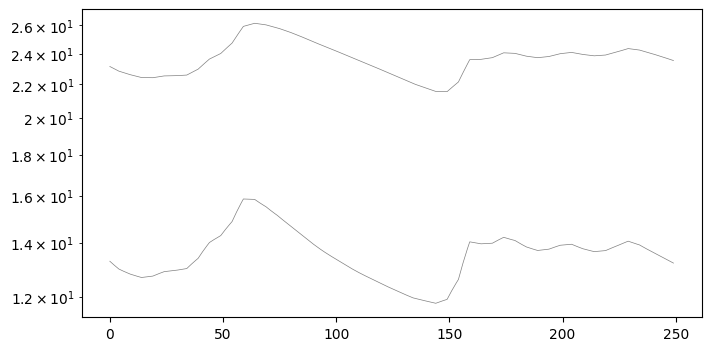

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(NCOL / 5, NROW / 5))

loc = (12, 39) # (row, col)

for i in range(N_REAL):
    ax.plot(heads_all[i, 1:, loc[0], loc[1]], c="k", lw=0.5, alpha=0.5)

ax.set_yscale("log")

plt.show()

## Step 4 — Spring discharge uncertainty

Standard deviation of spring discharge time series / different realizations.

In [10]:
discharge_all.shape

(2, 251)

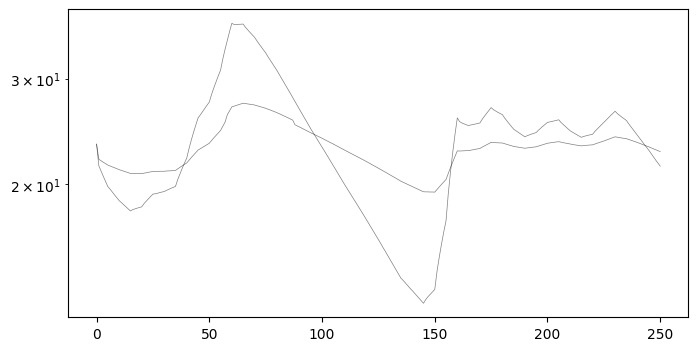

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(NCOL / 5, NROW / 5))

for i in range(N_REAL):
    ax.plot(discharge_all[i, :] * 1000, c="k", lw=0.5, alpha=0.5) # L / s

ax.set_yscale("log")

plt.show()